In [1]:
import os.path as op
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
short_color=np.array([255,0,0])/255.0
long_color=np.array([0,0,255])/255.0

In [5]:
all_tf={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
tf_time=None
tf_freqs=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_tf = data['all_tf'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_tf[hemi][epo_type][condition_name].append(np.mean(subj_tf[hemi][epo_type][condition_name],axis=0))
        tf_time = data['time']
        tf_freqs = data['freqs']
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_tf = data['all_tf'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_tf[hemi][epo_type][condition_name].append(np.mean(subj_tf[hemi][epo_type][condition_name],axis=0))
        tf_time = data['time']
        tf_freqs = data['freqs']

In [6]:
t_stim_idx=np.where((tf_time>=-1.5) & (tf_time<=.5))[0]
t_resp_idx=np.where((tf_time>=-.5) & (tf_time<=1.5))[0]
tf_stim_time=tf_time[t_stim_idx]
tf_resp_time=tf_time[t_resp_idx]
base_idx=np.where((tf_time>=-1.5) & (tf_time<=-1))[0]

f_idx=(tf_freqs>5) & (tf_freqs<100)
tf_freqs=tf_freqs[f_idx]

tf_bc={
    group: {
        epoch: {
            condition: {
                hemi: [] for hemi in ['contra','ipsi']
            } for condition in ['SHORT','LONG']
        } for epoch in ['STIM','RESP']
    } for group in ['TD','ASD']
}

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:            
            for condition in ['SHORT','LONG']:
                base_tf=np.mean(all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,base_idx],axis=-1)
                tf_stim=all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,t_stim_idx]                
                tf_stim=(tf_stim-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['STIM'][condition][hemi].append(tf_stim)
                
                tf_resp=all_tf[hemi]['RESP'][condition][s_idx][f_idx][:,t_resp_idx]
                tf_resp=(tf_resp-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['RESP'][condition][hemi].append(tf_resp)
        
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for s_idx, (subject_id, group) in enumerate(subjects):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_tf.npz')
    if op.exists(fname):
        for hemi in ['contra','ipsi']:
            for condition in ['SHORT','LONG']:
                base_tf=np.mean(all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,base_idx],axis=-1)
                tf_stim=all_tf[hemi]['STIM'][condition][s_idx][f_idx][:,t_stim_idx]
                tf_stim=(tf_stim-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['STIM'][condition][hemi].append(tf_stim)
                
                tf_resp=all_tf[hemi]['RESP'][condition][s_idx][f_idx][:,t_resp_idx]
                tf_resp=(tf_resp-base_tf[:,np.newaxis])/base_tf[:,np.newaxis]*100
                tf_bc[group]['RESP'][condition][hemi].append(tf_resp)
                
for group in ['TD','ASD']:
    for hemi in ['contra','ipsi']:
        for condition in ['SHORT','LONG']:
            for epoch in ['STIM','RESP']:
                tf_bc[group][epoch][condition][hemi]=np.array(tf_bc[group][epoch][condition][hemi])
                
n_td=tf_bc['TD']['RESP']['LONG']['contra'].shape[0]
n_asd=tf_bc['ASD']['RESP']['LONG']['contra'].shape[0]
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=37


# TD: SHORT-LONG

stat_fun(H1): min=-0.000002 max=41.890293
Running initial clustering …
Using 419 thresholds from 0.00 to 41.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.000004 max=30.742393
Running initial clustering …
Using 308 thresholds from 0.00 to 30.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 114095 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

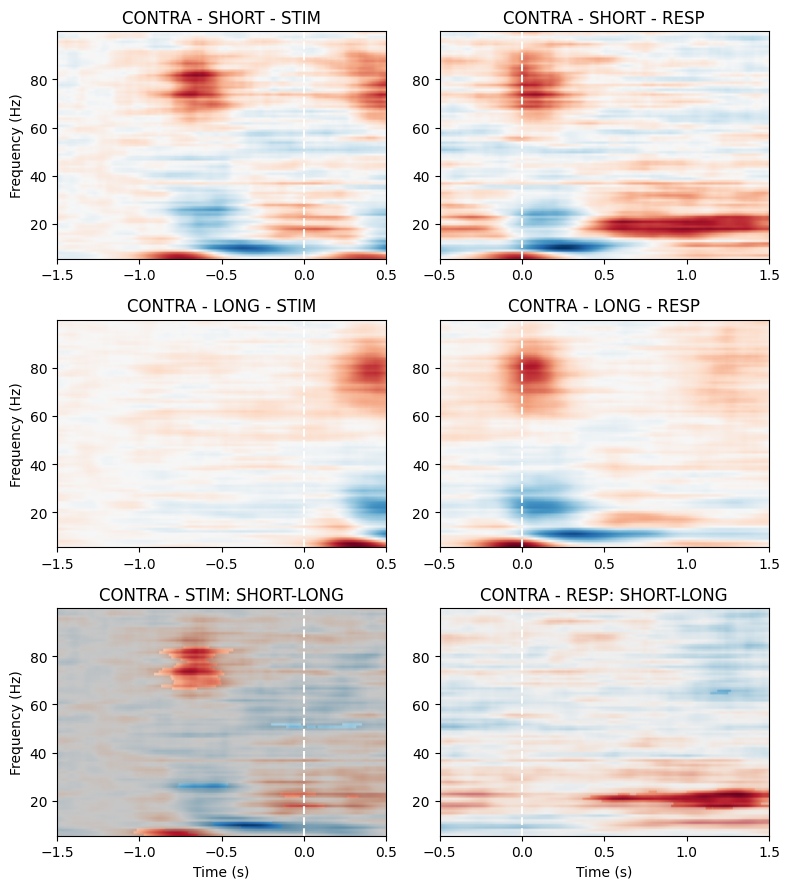

In [7]:
threshold_tfce = dict(start=0, step=0.1)

plt.figure(figsize=(8,9))
contra_stim_short=np.mean(tf_bc['TD']['STIM']['SHORT']['contra'],axis=0)
contra_resp_short=np.mean(tf_bc['TD']['RESP']['SHORT']['contra'],axis=0)
contra_stim_long=np.mean(tf_bc['TD']['STIM']['LONG']['contra'],axis=0)
contra_resp_long=np.mean(tf_bc['TD']['RESP']['LONG']['contra'],axis=0)

min_val=np.min(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:]
]))
max_val=np.max(np.vstack([
    contra_stim_short[:], 
    contra_resp_short[:], 
    contra_stim_long[:], 
    contra_resp_long[:], 
]))

ax=plt.subplot(3,2,1)
ax.imshow(
    contra_stim_short,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - SHORT - STIM')

ax=plt.subplot(3,2,2)
ax.imshow(
    contra_resp_short,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - SHORT - RESP')

ax=plt.subplot(3,2,3)
ax.imshow(
    contra_stim_long,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('CONTRA - LONG - STIM')

ax=plt.subplot(3,2,4)
ax.imshow(
    contra_resp_long,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    vmin=min_val,
    vmax=max_val,
    cmap='RdBu_r'
)
ax.axvline(0,color='w',linestyle='--')
ax.set_title('CONTRA - LONG - RESP')

contra_stim_diff=contra_stim_short-contra_stim_long
contra_resp_diff=contra_resp_short-contra_resp_long

all_diff=np.vstack([contra_stim_diff[:], contra_resp_diff[:]])
max_abs=np.max(np.abs(all_diff[:]))
n_jobs=2

ax=plt.subplot(3,2,5)

data = [tf_bc['TD']['STIM']['SHORT']['contra'], tf_bc['TD']['STIM']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    contra_stim_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(contra_stim_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.5  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_stim_time[0], tf_stim_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('CONTRA - STIM: SHORT-LONG')

ax=plt.subplot(3,2,6)

data = [tf_bc['TD']['RESP']['SHORT']['contra'], tf_bc['TD']['RESP']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data,
    threshold=threshold_tfce,
    n_permutations=1000,
    tail=0,
    n_jobs=n_jobs
)

ax.imshow(
    contra_resp_diff,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1], tf_freqs[0], tf_freqs[-1]),
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs
)

# build p-value map (same shape as stim_short_diff)
p_map = np.ones(contra_resp_diff.shape)

for clu, p_val in zip(clusters, cluster_p_values):
    if p_val < 0.05:
        p_map[clu] = p_val

# alpha: 0 where p < 0.05, semi-transparent elsewhere
alpha = np.ones_like(p_map) * 0.4
alpha[p_map < 0.05] = 0.0

# gray RGBA overlay
overlay = np.zeros(p_map.shape + (4,))
overlay[..., :3] = 0.9  # gray
overlay[..., 3] = alpha

ax.imshow(
    overlay,
    origin='lower',
    aspect='auto',
    extent=(tf_resp_time[0], tf_resp_time[-1],
            tf_freqs[0], tf_freqs[-1])
)

ax.axvline(0,color='w',linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_title('CONTRA - RESP: SHORT-LONG')

plt.tight_layout()

stat_fun(H1): min=-0.000001 max=41.890293
Running initial clustering …
Using 419 thresholds from 0.00 to 41.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 54045 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: STIM: SHORT vs LONG
  6 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0480]
    T range: [49.982, 91.939]
    Frequency: 5.5 ? 7.5 Hz
    Time: -1.058 ? -0.625 s
    Size (pixels): 593
  Region #2:
    p range: [0.0030, 0.0480]
    T range: [49.866, 73.457]
    Frequency: 7.5 ? 10.5 Hz
    Time: -0.592 ? -0.058 s
    Size (pixels): 860
  Region #3:
    p range: [0.0100, 0.0480]
    T range: [49.871, 61.262]
    Frequency: 17.6 ? 18.6 Hz
    Time: -0.195 ? 0.178 s
    Size (pixels): 343
  Region #4:
    p range: [0.0360, 0.0480]
    T range: [49.891, 52.667]
    Frequency: 17.6 ? 18.6 Hz
    Time: 0.227 ? 0.372 s
    Size (pixels): 103
  Region #5:
    p range: [0.0100, 0.0480]
    T range: [50.049, 61.831]
    Frequency: 20.6 ? 24.6 Hz
    Time: -0.227 ? 0.500 s
    Size (pixels): 902
  Region #6:
    p range: [0.0040, 0.0480]
    T range: [49.920, 73.101]
    Frequency: 25.6 ? 26.6 Hz
    Time: -0.792 ? -0.450 s
    Size (pixels): 410
s

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: RESP: SHORT vs LONG
  10 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0490]
    T range: [59.004, 146.619]
    Frequency: 16.6 ? 24.6 Hz
    Time: 0.325 ? 1.500 s
    Size (pixels): 4158
  Region #2:
    p range: [0.0410, 0.0490]
    T range: [58.907, 60.058]
    Frequency: 17.6 ? 17.6 Hz
    Time: -0.447 ? -0.347 s
    Size (pixels): 61
  Region #3:
    p range: [0.0340, 0.0490]
    T range: [58.896, 61.724]
    Frequency: 22.6 ? 22.6 Hz
    Time: -0.470 ? -0.227 s
    Size (pixels): 147
  Region #4:
    p range: [0.0370, 0.0490]
    T range: [58.902, 61.192]
    Frequency: 27.6 ? 27.6 Hz
    Time: 1.228 ? 1.362 s
    Size (pixels): 81
  Region #5:
    p range: [0.0400, 0.0490]
    T range: [58.937, 60.500]
    Frequency: 30.6 ? 31.6 Hz
    Time: 0.587 ? 0.710 s
    Size (pixels): 111
  Region #6:
    p range: [0.0490, 0.0490]
    T range: [58.889, 58.889]
    Frequency: 30.6 ? 30.6 Hz
    Time: 0.732 ? 0.752 s
    Size (pixels): 13
  

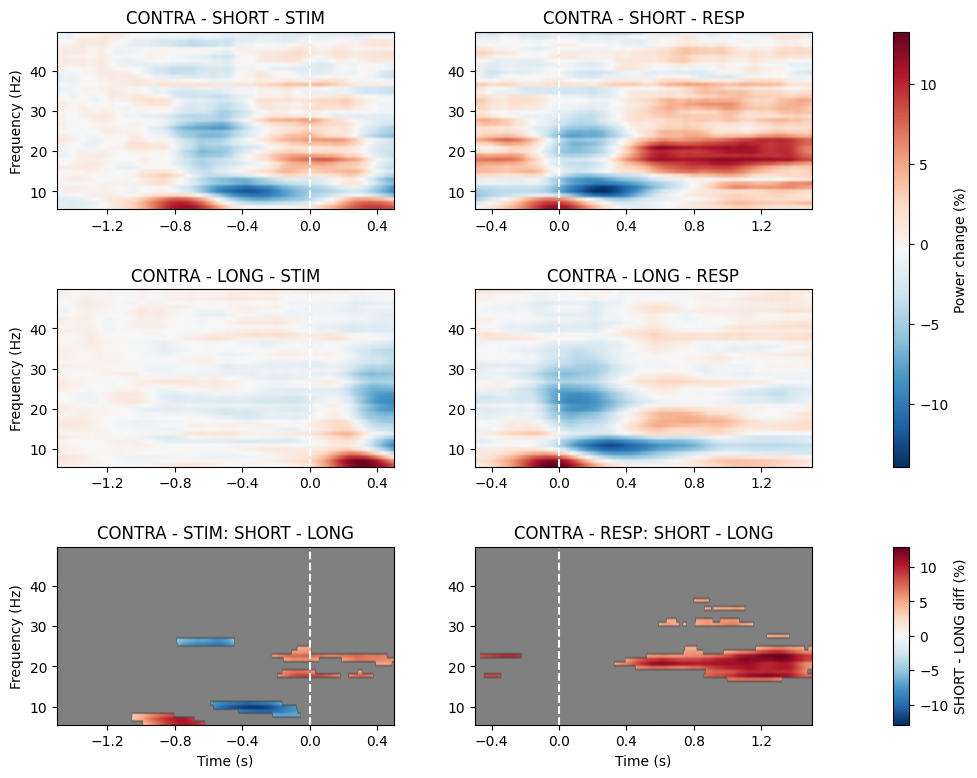

In [8]:
from scipy.ndimage import label as ndlabel
import matplotlib.gridspec as gridspec

threshold_tfce = dict(start=0, step=0.1)
n_jobs = 2

f50_idx     = tf_freqs <= 50
tf_freqs_50 = tf_freqs[f50_idx]

tf_bc_50 = {}
for group in ['TD', 'ASD']:
    tf_bc_50[group] = {}
    for epoch in ['STIM', 'RESP']:
        tf_bc_50[group][epoch] = {}
        for condition in ['SHORT', 'LONG']:
            tf_bc_50[group][epoch][condition] = {}
            for hemi in ['contra', 'ipsi']:
                tf_bc_50[group][epoch][condition][hemi] = \
                    tf_bc[group][epoch][condition][hemi][:, f50_idx, :]

contra_stim_short = np.mean(tf_bc_50['TD']['STIM']['SHORT']['contra'], axis=0)
contra_resp_short = np.mean(tf_bc_50['TD']['RESP']['SHORT']['contra'], axis=0)
contra_stim_long  = np.mean(tf_bc_50['TD']['STIM']['LONG']['contra'],  axis=0)
contra_resp_long  = np.mean(tf_bc_50['TD']['RESP']['LONG']['contra'],  axis=0)

all_vals = np.vstack([contra_stim_short, contra_resp_short,
                      contra_stim_long,  contra_resp_long])
vmin, vmax = np.min(all_vals), np.max(all_vals)

contra_stim_diff = contra_stim_short - contra_stim_long
contra_resp_diff = contra_resp_short - contra_resp_long
max_abs = np.max(np.abs(np.vstack([contra_stim_diff, contra_resp_diff])))

def print_cluster_results(T_obs, clusters, cluster_p_values, freqs, times, label):
    print(f"\n{'='*50}")
    print(f"Cluster results: {label}")
    print(f"{'='*50}")

    sig_mask = np.zeros(T_obs.shape, dtype=bool)
    for clu, p in zip(clusters, cluster_p_values):
        if p < 0.05:
            sig_mask[clu] = True

    if not sig_mask.any():
        print("No significant clusters (p < .05)")
        return

    labeled, n_regions = ndlabel(sig_mask)
    print(f"  {n_regions} contiguous significant region(s) found\n")

    for region_idx in range(1, n_regions + 1):
        region_mask = labeled == region_idx
        freq_idx, time_idx = np.where(region_mask)
        freq_range = (freqs[freq_idx.min()], freqs[freq_idx.max()])
        time_range = (times[time_idx.min()], times[time_idx.max()])

        region_ps = [p for clu, p in zip(clusters, cluster_p_values)
                     if p < 0.05 and region_mask[clu].any()]
        t_vals = T_obs[region_mask]

        print(f"  Region #{region_idx}:")
        print(f"    p range: [{min(region_ps):.4f}, {max(region_ps):.4f}]")
        print(f"    T range: [{t_vals.min():.3f}, {t_vals.max():.3f}]")
        print(f"    Frequency: {freq_range[0]:.1f} ? {freq_range[1]:.1f} Hz")
        print(f"    Time: {time_range[0]:.3f} ? {time_range[1]:.3f} s")
        print(f"    Size (pixels): {region_mask.sum()}")

# --- Layout: 3 rows × 3 cols, last col is narrow colorbar axes ---
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(
    3, 3,
    width_ratios=[1, 1, 0.05],
    hspace=0.45,
    wspace=0.35,
)

axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(2)] for r in range(3)])
cax_top = fig.add_subplot(gs[0:2, 2])  # shared colorbar for rows 0?1
cax_bot = fig.add_subplot(gs[2,   2])  # shared colorbar for row 2

# --- Rows 0 & 1: condition TFRs ---
plot_specs = [
    (axes[0, 0], contra_stim_short, tf_stim_time, 'CONTRA - SHORT - STIM', 'Frequency (Hz)'),
    (axes[0, 1], contra_resp_short, tf_resp_time, 'CONTRA - SHORT - RESP', None),
    (axes[1, 0], contra_stim_long,  tf_stim_time, 'CONTRA - LONG - STIM',  'Frequency (Hz)'),
    (axes[1, 1], contra_resp_long,  tf_resp_time, 'CONTRA - LONG - RESP',  None),
]

for ax, data_2d, times, title, ylabel in plot_specs:
    im_top = ax.imshow(
        data_2d, origin='lower', aspect='auto',
        extent=(times[0], times[-1], tf_freqs_50[0], tf_freqs_50[-1]),
        cmap='RdBu_r', vmin=vmin, vmax=vmax,
    )
    ax.axvline(0, color='w', linestyle='--')
    ax.set_title(title)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    if ylabel:
        ax.set_ylabel(ylabel)

fig.colorbar(im_top, cax=cax_top, label='Power change (%)')

# --- Row 2: difference maps with cluster masking ---
for ax, cond, diff_data, times, title, ylabel, xlabel in [
    (axes[2, 0], 'STIM', contra_stim_diff, tf_stim_time,
     'CONTRA - STIM: SHORT - LONG', 'Frequency (Hz)', 'Time (s)'),
    (axes[2, 1], 'RESP', contra_resp_diff, tf_resp_time,
     'CONTRA - RESP: SHORT - LONG', None,              'Time (s)'),
]:
    short_data = tf_bc_50['TD'][cond]['SHORT']['contra']
    long_data  = tf_bc_50['TD'][cond]['LONG']['contra']
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        [short_data, long_data],
        threshold=threshold_tfce, n_permutations=1000, tail=0, n_jobs=n_jobs,
    )
    print_cluster_results(T_obs, clusters, cluster_p_values, tf_freqs_50, times,
                          f"{cond}: SHORT vs LONG")

    sig_mask = np.zeros(diff_data.shape, dtype=bool)
    for clu, p in zip(clusters, cluster_p_values):
        if p < 0.05:
            sig_mask[clu] = True

    extent = (times[0], times[-1], tf_freqs_50[0], tf_freqs_50[-1])
    ax.imshow(np.zeros_like(diff_data), origin='lower', aspect='auto',
              extent=extent, cmap='gray', vmin=-1, vmax=1)
    im_bot = ax.imshow(
        np.ma.masked_where(~sig_mask, diff_data),
        origin='lower', aspect='auto', extent=extent,
        cmap='RdBu_r', vmin=-max_abs, vmax=max_abs,
    )
    ax.axvline(0, color='w', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    if ylabel:
        ax.set_ylabel(ylabel)

fig.colorbar(im_bot, cax=cax_bot, label='SHORT - LONG diff (%)')
fig.savefig('td_contra_tfr_short_vs_long.png', dpi=150, bbox_inches='tight')

plt.show()

In [9]:
all_beta_power={
    group: {
        hemi: {        
            epo_type: {
                condition_name: [] for condition_name in condition_names
            } for epo_type in epoch_types
        } for hemi in ['ipsi','contra']
    } for group in ['TD','ASD']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    if group=='TD':
        subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
        fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
        if op.exists(fname):
            data = np.load(fname, allow_pickle=True)
            subj_beta_power = data['all_beta_pow'].item()
            for hemi in ['ipsi','contra']:
                for epo_type in epoch_types:
                    for condition_name in condition_names:
                        all_beta_power[group][hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
            power_time = data['time']
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    if group=='TD':
        subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
        fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
        if op.exists(fname):
            data = np.load(fname, allow_pickle=True)
            subj_beta_power = data['all_beta_pow'].item()
            for hemi in ['ipsi','contra']:
                for epo_type in epoch_types:
                    for condition_name in condition_names:
                        all_beta_power[group][hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
            power_time = data['time']

In [10]:
t_stim_idx=np.where((power_time>=-1.5) & (power_time<=0.5))[0]
t_resp_idx=np.where((power_time>=-.5) & (power_time<=1.5))[0]
base_idx=np.where((power_time>=-1.5) & (power_time<=-1))[0]
        
beta_pow_bc={
    group: {
        epoch: {
            condition: {
                hemi: [] for hemi in ['contra','ipsi']
            } for condition in ['SHORT','LONG']
        } for epoch in ['STIM','RESP']
    } for group in ['TD','ASD']
}

s_idx=0

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for subject_id, group in subjects:
    if group=='TD':
        subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
        fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
        if op.exists(fname):
            for hemi in ['contra','ipsi']:                
                for condition in ['SHORT','LONG']:
                    base_pow=np.mean(all_beta_power[group][hemi]['STIM'][condition][s_idx][base_idx])
                    
                    b_pow_stim=all_beta_power[group][hemi]['STIM'][condition][s_idx][t_stim_idx]
                    b_pow_stim=(b_pow_stim-base_pow)/base_pow*100

                    b_pow_resp=all_beta_power[group][hemi]['RESP'][condition][s_idx][t_resp_idx]
                    b_pow_resp=(b_pow_resp-base_pow)/base_pow*100

                    beta_pow_bc[group]['STIM'][condition][hemi].append(b_pow_stim)
                    beta_pow_bc[group]['RESP'][condition][hemi].append(b_pow_resp)
            s_idx+=1

        
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
# Collect subject tuples first to keep the main body clean for joblib
subjects = list(df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None))
for subject_id, group in subjects:
    if group=='TD':
        subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
        fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
        if op.exists(fname):
            for hemi in ['contra','ipsi']:
                for condition in ['SHORT','LONG']:
                    base_pow=np.mean(all_beta_power[group][hemi]['STIM'][condition][s_idx][base_idx])
                    b_pow_stim=all_beta_power[group][hemi]['STIM'][condition][s_idx][t_stim_idx]
                    b_pow_stim=(b_pow_stim-base_pow)/base_pow*100

                    b_pow_resp=all_beta_power[group][hemi]['RESP'][condition][s_idx][t_resp_idx]
                    b_pow_resp=(b_pow_resp-base_pow)/base_pow*100

                    beta_pow_bc[group]['STIM'][condition][hemi].append(b_pow_stim)
                    beta_pow_bc[group]['RESP'][condition][hemi].append(b_pow_resp)
            s_idx+=1
                
for group in ['TD','ASD']:
    for hemi in ['contra','ipsi']:
        for condition in ['SHORT','LONG']:
            for epoch in ['STIM','RESP']:
                beta_pow_bc[group][epoch][condition][hemi]=np.array(beta_pow_bc[group][epoch][condition][hemi])
                
n_td=beta_pow_bc['TD']['RESP']['LONG']['contra'].shape[0]
n_asd=beta_pow_bc['ASD']['RESP']['LONG']['contra'].shape[0]
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=0


stat_fun(H1): min=-6.821164 max=4.880558
Running initial clustering …
Using 683 thresholds from 0.00 to 6.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - STIM: SHORT vs LONG
  3 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0470]
    T range: [-0.068, -0.033]
    Time: -0.758 ? -0.422 s
    Size (pixels): 203
  Region #2:
    p range: [0.0060, 0.0480]
    T range: [0.033, 0.046]
    Time: -0.187 ? 0.088 s
    Size (pixels): 166
  Region #3:
    p range: [0.0020, 0.0490]
    T range: [0.033, 0.049]
    Time: 0.180 ? 0.500 s
    Size (pixels): 193
stat_fun(H1): min=1.473577 max=6.846058
Running initial clustering …
Using 685 thresholds from 0.00 to 6.84 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP: SHORT vs LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0020, 0.0490]
    T range: [0.030, 0.046]
    Time: -0.500 ? -0.198 s
    Size (pixels): 182
  Region #2:
    p range: [0.0010, 0.0490]
    T range: [0.030, 0.068]
    Time: 0.215 ? 1.500 s
    Size (pixels): 772


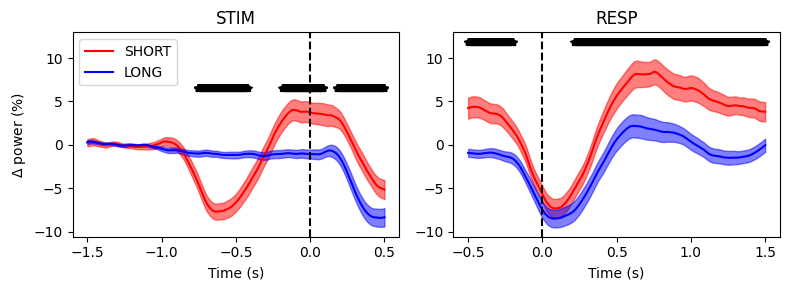

In [11]:
from scipy.ndimage import label as ndlabel

def print_cluster_results(T_obs, clusters, cluster_p_values, freqs, times, label):
    print(f"\n{'='*50}")
    print(f"Cluster results: {label}")
    print(f"{'='*50}")

    sig_mask = np.zeros(T_obs.shape, dtype=bool)
    for clu, p in zip(clusters, cluster_p_values):
        if p < 0.05:
            sig_mask[clu] = True

    if not sig_mask.any():
        print("No significant clusters (p < .05)")
        return

    labeled, n_regions = ndlabel(sig_mask)
    print(f"  {n_regions} contiguous significant region(s) found\n")

    for region_idx in range(1, n_regions + 1):
        region_mask = labeled == region_idx
        indices = np.where(region_mask)
        t_vals = T_obs[region_mask]
        region_ps = [p for clu, p in zip(clusters, cluster_p_values)
                     if p < 0.05 and region_mask[clu].any()]

        print(f"  Region #{region_idx}:")
        print(f"    p range: [{min(region_ps):.4f}, {max(region_ps):.4f}]")
        print(f"    T range: [{t_vals.min():.3f}, {t_vals.max():.3f}]")

        if T_obs.ndim == 2:
            freq_idx, time_idx = indices
            print(f"    Frequency: {freqs[freq_idx.min()]:.1f} ? {freqs[freq_idx.max()]:.1f} Hz")
            print(f"    Time: {times[time_idx.min()]:.3f} ? {times[time_idx.max()]:.3f} s")
        else:
            time_idx = indices[0]
            print(f"    Time: {times[time_idx.min()]:.3f} ? {times[time_idx.max()]:.3f} s")

        print(f"    Size (pixels): {region_mask.sum()}")


plt.figure(figsize=(8,3))

def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

axes = []
ax = plt.subplot(1, 2, 1)

m_pow = np.mean(beta_pow_bc['TD']['STIM']['SHORT']['contra'], axis=0)
se_pow = np.std(beta_pow_bc['TD']['STIM']['SHORT']['contra'], axis=0) / np.sqrt(beta_pow_bc['TD']['STIM']['SHORT']['contra'].shape[0])
ax.plot(power_time[t_stim_idx], m_pow, label='SHORT', color=short_color)
ax.fill_between(power_time[t_stim_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=short_color)

m_pow = np.mean(beta_pow_bc['TD']['STIM']['LONG']['contra'], axis=0)
se_pow = np.std(beta_pow_bc['TD']['STIM']['LONG']['contra'], axis=0) / np.sqrt(beta_pow_bc['TD']['STIM']['LONG']['contra'].shape[0])
ax.plot(power_time[t_stim_idx], m_pow, label='LONG', color=long_color)
ax.fill_between(power_time[t_stim_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=long_color)

data = [beta_pow_bc['TD']['STIM']['SHORT']['contra'], beta_pow_bc['TD']['STIM']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data, stat_fun=paired_t, threshold=threshold_tfce, n_permutations=1000, tail=0
)
print_cluster_results(T_obs, clusters, cluster_p_values, None, power_time[t_stim_idx], "Beta power - STIM: SHORT vs LONG")

yl = ax.get_ylim()
py = yl[1] + .1 * (yl[1] - 0)
for p_idx, p_val in enumerate(cluster_p_values):
    if p_val < 0.05:
        ax.plot(power_time[t_stim_idx][p_idx], py, 'k*')

ax.axvline(0, color='k', linestyle='--')
ax.set_title('STIM')
ax.legend()
ax.set_ylabel(r'$\Delta$ power (%)')
ax.set_xlabel('Time (s)')
axes.append(ax)

ax = plt.subplot(1, 2, 2)

m_pow = np.mean(beta_pow_bc['TD']['RESP']['SHORT']['contra'], axis=0)
se_pow = np.std(beta_pow_bc['TD']['RESP']['SHORT']['contra'], axis=0) / np.sqrt(beta_pow_bc['TD']['RESP']['SHORT']['contra'].shape[0])
ax.plot(power_time[t_resp_idx], m_pow, label='SHORT', color=short_color)
ax.fill_between(power_time[t_resp_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=short_color)

m_pow = np.mean(beta_pow_bc['TD']['RESP']['LONG']['contra'], axis=0)
se_pow = np.std(beta_pow_bc['TD']['RESP']['LONG']['contra'], axis=0) / np.sqrt(beta_pow_bc['TD']['RESP']['LONG']['contra'].shape[0])
ax.plot(power_time[t_resp_idx], m_pow, label='LONG', color=long_color)
ax.fill_between(power_time[t_resp_idx], m_pow-se_pow, m_pow+se_pow, alpha=0.5, color=long_color)

data = [beta_pow_bc['TD']['RESP']['SHORT']['contra'], beta_pow_bc['TD']['RESP']['LONG']['contra']]
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
    data, stat_fun=paired_t, threshold=threshold_tfce, n_permutations=1000, tail=0
)
print_cluster_results(T_obs, clusters, cluster_p_values, None, power_time[t_resp_idx], "Beta power - RESP: SHORT vs LONG")

yl = ax.get_ylim()
py = yl[1] + .1 * (yl[1] - 0)
for p_idx, p_val in enumerate(cluster_p_values):
    if p_val < 0.05:
        ax.plot(power_time[t_resp_idx][p_idx], py, 'k*')

ax.axvline(0, color='k', linestyle='--')
ax.set_title('RESP')
ax.set_xlabel('Time (s)')
axes.append(ax)

ymins, ymaxs = zip(*[ax.get_ylim() for ax in axes])
ymin, ymax = np.min(ymins), np.max(ymaxs)
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

Median age: 14.6 | N low: 17 | N high: 16
stat_fun(H1): min=-3.123953 max=1.379228
Running initial clustering …
Using 313 thresholds from 0.00 to 3.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - STIM SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.728411 max=1.651481
Running initial clustering …
Using 273 thresholds from 0.00 to 2.72 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - STIM LONG: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.823822 max=1.038344
Running initial clustering …
Using 283 thresholds from 0.00 to 2.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.314457 max=1.328464
Running initial clustering …
Using 232 thresholds from 0.00 to 2.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP LONG: high vs low age
No significant clusters (p < .05)


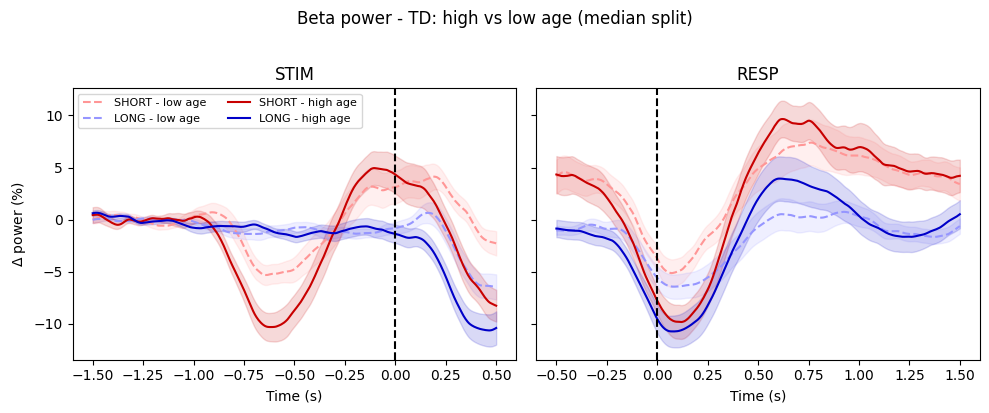

In [12]:
from scipy.ndimage import label as ndlabel

def print_cluster_results(T_obs, clusters, cluster_p_values, freqs, times, label):
    print(f"\n{'='*50}")
    print(f"Cluster results: {label}")
    print(f"{'='*50}")

    sig_mask = np.zeros(T_obs.shape, dtype=bool)
    for clu, p in zip(clusters, cluster_p_values):
        if p < 0.05:
            sig_mask[clu] = True

    if not sig_mask.any():
        print("No significant clusters (p < .05)")
        return

    labeled, n_regions = ndlabel(sig_mask)
    print(f"  {n_regions} contiguous significant region(s) found\n")

    for region_idx in range(1, n_regions + 1):
        region_mask = labeled == region_idx
        indices = np.where(region_mask)
        t_vals = T_obs[region_mask]
        region_ps = [p for clu, p in zip(clusters, cluster_p_values)
                     if p < 0.05 and region_mask[clu].any()]

        print(f"  Region #{region_idx}:")
        print(f"    p range: [{min(region_ps):.4f}, {max(region_ps):.4f}]")
        print(f"    T range: [{t_vals.min():.3f}, {t_vals.max():.3f}]")

        if T_obs.ndim == 2:
            freq_idx, time_idx = indices
            print(f"    Frequency: {freqs[freq_idx.min()]:.1f} ? {freqs[freq_idx.max()]:.1f} Hz")
            print(f"    Time: {times[time_idx.min()]:.3f} ? {times[time_idx.max()]:.3f} s")
        else:
            time_idx = indices[0]
            print(f"    Time: {times[time_idx.min()]:.3f} ? {times[time_idx.max()]:.3f} s")

        print(f"    Size (pixels): {region_mask.sum()}")


# --- collect ages in the same order as beta_pow_bc subjects were appended ---
subject_ages = []
for csv_file in [
    op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'),
    op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv')
]:
    demo = pd.read_csv(csv_file)
    for _, row in demo.iterrows():
        subject_id = row['ParticipantID']
        group      = row['Status']
        if group == 'TD':
            fname = op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',
                            subject_id, f'{subject_id}_beta_power.npz')
            if op.exists(fname):
                subject_ages.append(row['AgeAtImaging'])

subject_ages = np.array(subject_ages)
median_age   = np.median(subject_ages)
low_idx      = np.where(subject_ages <= median_age)[0]
high_idx     = np.where(subject_ages >  median_age)[0]
print(f'Median age: {median_age:.1f} | N low: {len(low_idx)} | N high: {len(high_idx)}')

def ttest_ind_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_ind(x, y, axis=axis, nan_policy='omit')
    return tvals

ind_t = partial(ttest_ind_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

age_colors = {
    'low':  {'SHORT': np.array([255, 150, 150]) / 255,
             'LONG':  np.array([150, 150, 255]) / 255},
    'high': {'SHORT': np.array([200,   0,   0]) / 255,
             'LONG':  np.array([  0,   0, 200]) / 255},
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, epoch, t_idx in zip(axes, ['STIM', 'RESP'], [t_stim_idx, t_resp_idx]):
    for age_label, idx in [('low', low_idx), ('high', high_idx)]:
        for condition in ['SHORT', 'LONG']:
            data_sub = beta_pow_bc['TD'][epoch][condition]['contra'][idx]
            m   = np.mean(data_sub, axis=0)
            se  = np.std(data_sub, axis=0) / np.sqrt(len(idx))
            col = age_colors[age_label][condition]
            ls  = '-' if age_label == 'high' else '--'
            ax.plot(power_time[t_idx], m,
                    color=col, linestyle=ls,
                    label=f'{condition} - {age_label} age')
            ax.fill_between(power_time[t_idx], m - se, m + se,
                            color=col, alpha=0.15)

    for condition, offset in [('SHORT', 0.02), ('LONG', 0.04)]:
        data = [
            beta_pow_bc['TD'][epoch][condition]['contra'][high_idx],
            beta_pow_bc['TD'][epoch][condition]['contra'][low_idx]
        ]
        T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
            data, stat_fun=ind_t, threshold=threshold_tfce, n_permutations=1000, tail=0
        )
        print_cluster_results(T_obs, clusters, cluster_p_values, None, power_time[t_idx],
                              f"Beta power - {epoch} {condition}: high vs low age")

        yl = ax.get_ylim()
        py = yl[1] + offset * (yl[1] - yl[0])
        col = age_colors['high'][condition]
        for clu, p_val in zip(clusters, cluster_p_values):
            if p_val < 0.05:
                ax.plot(power_time[t_idx][clu[0]], np.full(len(clu[0]), py),
                        color=col, linewidth=3)

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(epoch)
    ax.set_xlabel('Time (s)')

axes[0].set_ylabel(r'$\Delta$ power (%)')
axes[0].legend(fontsize=8, ncol=2)
plt.suptitle('Beta power - TD: high vs low age (median split)', y=1.02)
plt.tight_layout()
plt.show()

In [13]:

print(pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv')).columns.tolist())

['ParticipantID', 'Handedness', 'Gender', 'Status', 'AgeAtImaging']


Median age: 14.6 | N low: 17 | N high: 16
stat_fun(H1): min=-6.821164 max=4.880558
Running initial clustering …
Using 683 thresholds from 0.00 to 6.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - STIM: SHORT vs LONG
  3 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0440]
    T range: [-0.068, -0.034]
    Time: -0.757 - -0.423 s
    Size (pixels): 201
  Region #2:
    p range: [0.0040, 0.0490]
    T range: [0.033, 0.046]
    Time: -0.185 - 0.087 s
    Size (pixels): 164
  Region #3:
    p range: [0.0020, 0.0460]
    T range: [0.034, 0.049]
    Time: 0.183 - 0.500 s
    Size (pixels): 191
stat_fun(H1): min=1.473577 max=6.846058
Running initial clustering …
Using 685 thresholds from 0.00 to 6.84 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP: SHORT vs LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0030, 0.0490]
    T range: [0.029, 0.046]
    Time: -0.500 - -0.175 s
    Size (pixels): 196
  Region #2:
    p range: [0.0010, 0.0490]
    T range: [0.029, 0.068]
    Time: 0.210 - 1.500 s
    Size (pixels): 775
stat_fun(H1): min=-3.123953 max=1.379228
Running initial clustering …
Using 313 thresholds from 0.00 to 3.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


...


Cluster results: Beta power - STIM LONG: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.823822 max=1.038344
Running initial clustering …
Using 283 thresholds from 0.00 to 2.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.314457 max=1.328464
Running initial clustering …
Using 232 thresholds from 0.00 to 2.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP LONG: high vs low age
No significant clusters (p < .05)


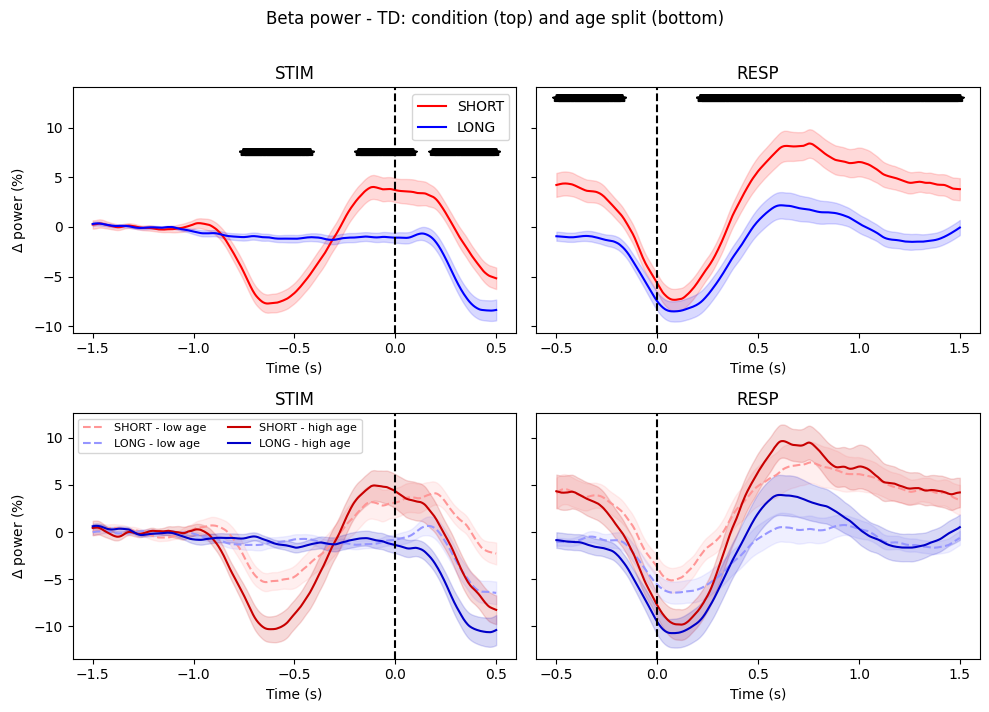

In [14]:
from scipy.ndimage import label as ndlabel

def print_cluster_results(T_obs, clusters, cluster_p_values, freqs, times, label):
    print(f"\n{'='*50}")
    print(f"Cluster results: {label}")
    print(f"{'='*50}")

    sig_mask = np.zeros(T_obs.shape, dtype=bool)
    for clu, p in zip(clusters, cluster_p_values):
        if p < 0.05:
            sig_mask[clu] = True

    if not sig_mask.any():
        print("No significant clusters (p < .05)")
        return

    labeled, n_regions = ndlabel(sig_mask)
    print(f"  {n_regions} contiguous significant region(s) found\n")

    for region_idx in range(1, n_regions + 1):
        region_mask = labeled == region_idx
        indices = np.where(region_mask)
        t_vals = T_obs[region_mask]
        region_ps = [p for clu, p in zip(clusters, cluster_p_values)
                     if p < 0.05 and region_mask[clu].any()]

        print(f"  Region #{region_idx}:")
        print(f"    p range: [{min(region_ps):.4f}, {max(region_ps):.4f}]")
        print(f"    T range: [{t_vals.min():.3f}, {t_vals.max():.3f}]")

        if T_obs.ndim == 2:
            freq_idx, time_idx = indices
            print(f"    Frequency: {freqs[freq_idx.min()]:.1f} - {freqs[freq_idx.max()]:.1f} Hz")
            print(f"    Time: {times[time_idx.min()]:.3f} - {times[time_idx.max()]:.3f} s")
        else:
            time_idx = indices[0]
            print(f"    Time: {times[time_idx.min()]:.3f} - {times[time_idx.max()]:.3f} s")

        print(f"    Size (pixels): {region_mask.sum()}")


# --- collect ages ---
subject_ages = []
for csv_file in [
    op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'),
    op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv')
]:
    demo = pd.read_csv(csv_file)
    for _, row in demo.iterrows():
        subject_id = row['ParticipantID']
        group      = row['Status']
        if group == 'TD':
            fname = op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',
                            subject_id, f'{subject_id}_beta_power.npz')
            if op.exists(fname):
                subject_ages.append(row['AgeAtImaging'])

subject_ages = np.array(subject_ages)
median_age   = np.median(subject_ages)
low_idx      = np.where(subject_ages <= median_age)[0]
high_idx     = np.where(subject_ages >  median_age)[0]
print(f'Median age: {median_age:.1f} | N low: {len(low_idx)} | N high: {len(high_idx)}')

# --- stat functions ---
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

def ttest_ind_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_ind(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
ind_t    = partial(ttest_ind_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

age_colors = {
    'low':  {'SHORT': np.array([255, 150, 150]) / 255,
             'LONG':  np.array([150, 150, 255]) / 255},
    'high': {'SHORT': np.array([200,   0,   0]) / 255,
             'LONG':  np.array([  0,   0, 200]) / 255},
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey='row')

epoch_list = ['STIM', 'RESP']
t_idx_list = [t_stim_idx, t_resp_idx]

# --- Row 0: SHORT vs LONG (paired) ---
row0_axes = []
for col, (epoch, t_idx) in enumerate(zip(epoch_list, t_idx_list)):
    ax = axes[0, col]

    for condition, color in [('SHORT', short_color), ('LONG', long_color)]:
        m  = np.mean(beta_pow_bc['TD'][epoch][condition]['contra'], axis=0)
        se = np.std( beta_pow_bc['TD'][epoch][condition]['contra'], axis=0) / \
             np.sqrt(beta_pow_bc['TD'][epoch][condition]['contra'].shape[0])
        ax.plot(power_time[t_idx], m, color=color, label=condition)
        ax.fill_between(power_time[t_idx], m - se, m + se, color=color, alpha=0.15)

    data = [beta_pow_bc['TD'][epoch]['SHORT']['contra'],
            beta_pow_bc['TD'][epoch]['LONG']['contra']]
    T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
        data, stat_fun=paired_t, threshold=threshold_tfce, n_permutations=1000, tail=0
    )
    print_cluster_results(T_obs, clusters, cluster_p_values, None,
                          power_time[t_idx], f"Beta power - {epoch}: SHORT vs LONG")

    yl = ax.get_ylim()
    py = yl[1] + 0.1 * (yl[1] - yl[0])
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(power_time[t_idx][p_idx], py, 'k*')

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(epoch)
    ax.set_xlabel('Time (s)')
    if col == 0:
        ax.set_ylabel(r'$\Delta$ power (%)')
        ax.legend()
    row0_axes.append(ax)

# --- Row 1: high vs low age (independent) ---
row1_axes = []
for col, (epoch, t_idx) in enumerate(zip(epoch_list, t_idx_list)):
    ax = axes[1, col]

    for age_label, idx in [('low', low_idx), ('high', high_idx)]:
        for condition in ['SHORT', 'LONG']:
            data_sub = beta_pow_bc['TD'][epoch][condition]['contra'][idx]
            m   = np.mean(data_sub, axis=0)
            se  = np.std(data_sub,  axis=0) / np.sqrt(len(idx))
            col_ = age_colors[age_label][condition]
            ls   = '-' if age_label == 'high' else '--'
            ax.plot(power_time[t_idx], m, color=col_, linestyle=ls,
                    label=f'{condition} - {age_label} age')
            ax.fill_between(power_time[t_idx], m - se, m + se,
                            color=col_, alpha=0.15)

    for condition, offset in [('SHORT', 0.02), ('LONG', 0.04)]:
        data = [
            beta_pow_bc['TD'][epoch][condition]['contra'][high_idx],
            beta_pow_bc['TD'][epoch][condition]['contra'][low_idx],
        ]
        T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
            data, stat_fun=ind_t, threshold=threshold_tfce, n_permutations=1000, tail=0
        )
        print_cluster_results(T_obs, clusters, cluster_p_values, None, power_time[t_idx],
                              f"Beta power - {epoch} {condition}: high vs low age")

        yl = ax.get_ylim()
        py = yl[1] + offset * (yl[1] - yl[0])
        sig_color = age_colors['high'][condition]
        for clu, p_val in zip(clusters, cluster_p_values):
            if p_val < 0.05:
                ax.plot(power_time[t_idx][clu[0]], np.full(len(clu[0]), py),
                        color=sig_color, linewidth=3)

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(epoch)
    ax.set_xlabel('Time (s)')
    if col == 0:
        ax.set_ylabel(r'$\Delta$ power (%)')
        ax.legend(fontsize=8, ncol=2)
    row1_axes.append(ax)

# --- align ylims within each row ---
for row_axes in [row0_axes, row1_axes]:
    ymins, ymaxs = zip(*[ax.get_ylim() for ax in row_axes])
    for ax in row_axes:
        ax.set_ylim(np.min(ymins), np.max(ymaxs))
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))

fig.suptitle('Beta power - TD: condition (top) and age split (bottom)', y=1.01)
plt.tight_layout()
plt.savefig('td_contra_beta_power.png', dpi=150, bbox_inches='tight')
plt.show()

33rd pct: 12.9 | 67th pct: 15.6
youngest: n=11 | middle: n=11 | oldest: n=11
stat_fun(H1): min=-6.821164 max=4.880558
Running initial clustering …
Using 683 thresholds from 0.00 to 6.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - STIM: SHORT vs LONG
  3 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0440]
    T range: [-0.068, -0.033]
    Time: -0.758 - -0.422 s
    Size (pixels): 203
  Region #2:
    p range: [0.0030, 0.0490]
    T range: [0.033, 0.046]
    Time: -0.188 - 0.090 s
    Size (pixels): 168
  Region #3:
    p range: [0.0010, 0.0460]
    T range: [0.033, 0.049]
    Time: 0.180 - 0.500 s
    Size (pixels): 193
stat_fun(H1): min=1.473577 max=6.846058
Running initial clustering …
Using 685 thresholds from 0.00 to 6.84 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP: SHORT vs LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0020, 0.0490]
    T range: [0.030, 0.046]
    Time: -0.500 - -0.198 s
    Size (pixels): 182
  Region #2:
    p range: [0.0010, 0.0490]
    T range: [0.030, 0.068]
    Time: 0.215 - 1.500 s
    Size (pixels): 772
stat_fun(H1): min=-3.184484 max=1.933083
Running initial clustering …
Using 319 thresholds from 0.00 to 3.18 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


...


Cluster results: Beta power - RESP LONG: youngest vs middle
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0090, 0.0490]
    T range: [0.029, 0.037]
    Time: -0.300 - 0.067 s
    Size (pixels): 221
stat_fun(H1): min=-0.942671 max=0.846220
Running initial clustering …
Using 95 thresholds from 0.00 to 0.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP LONG: middle vs oldest
No significant clusters (p < .05)
stat_fun(H1): min=-1.755563 max=4.183110
Running initial clustering …
Using 419 thresholds from 0.00 to 4.18 for TFCE computation (h_power=2.00, e_power=0.50)
Found 1201 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Beta power - RESP LONG: youngest vs oldest
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0020, 0.0490]
    T range: [0.032, 0.042]
    Time: -0.190 - 0.187 s
    Size (pixels): 227


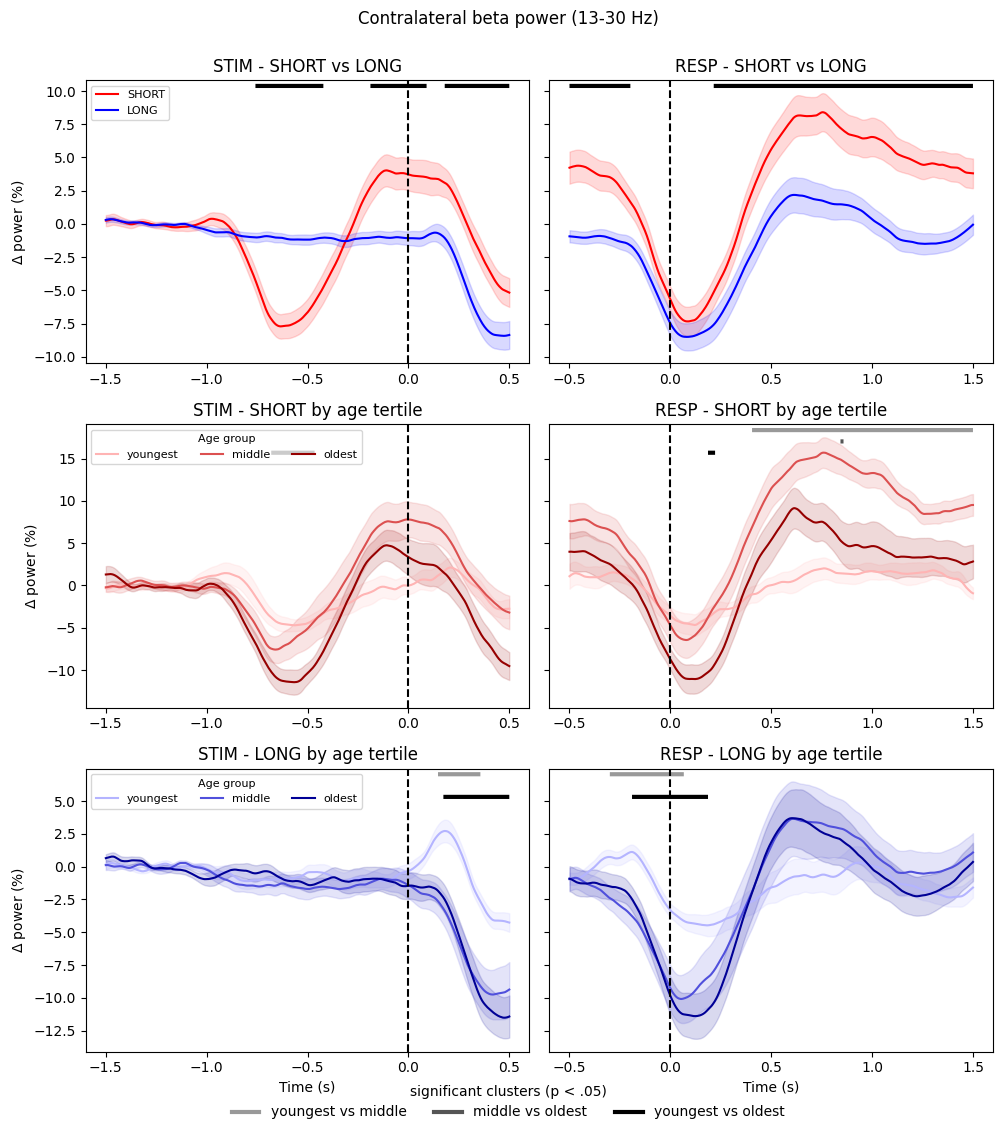

In [20]:
from matplotlib.transforms import blended_transform_factory

# --- collect ages ---
subject_ages = []
for csv_file in [
    op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'),
    op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv')
]:
    demo = pd.read_csv(csv_file)
    for _, row in demo.iterrows():
        subject_id = row['ParticipantID']
        group      = row['Status']
        if group == 'TD':
            fname = op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',
                            subject_id, f'{subject_id}_beta_power.npz')
            if op.exists(fname):
                subject_ages.append(row['AgeAtImaging'])

subject_ages = np.array(subject_ages)
t33 = np.percentile(subject_ages, 33.33)
t67 = np.percentile(subject_ages, 66.67)
age_idx = {
    'low':  np.where(subject_ages <= t33)[0],
    'mid':  np.where((subject_ages > t33) & (subject_ages <= t67))[0],
    'high': np.where(subject_ages > t67)[0],
}
age_names  = {'low': 'youngest', 'mid': 'middle', 'high': 'oldest'}

print(f'33rd pct: {t33:.1f} | 67th pct: {t67:.1f}')
print(' | '.join(f'{age_names[k]}: n={len(v)}' for k, v in age_idx.items()))

# --- stat functions ---
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

def ttest_ind_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_ind(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
ind_t    = partial(ttest_ind_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

def plot_sig(ax, times, clusters, cluster_p_values, y_frac, color):
    mask = np.zeros(len(times), dtype=bool)
    for clu, p_val in zip(clusters, cluster_p_values):
        if p_val < 0.05:
            mask[clu[0]] = True
    if not mask.any():
        return
    t_sig = times.astype(float).copy()
    t_sig[~mask] = np.nan
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.plot(t_sig, np.full(len(t_sig), y_frac), transform=trans,
            color=color, linewidth=3, solid_capstyle='butt', clip_on=False)

age_shades = {
    'SHORT': {'low': np.array([255, 180, 180]) / 255,
              'mid': np.array([220,  80,  80]) / 255,
              'high': np.array([150,   0,   0]) / 255},
    'LONG':  {'low': np.array([180, 180, 255]) / 255,
              'mid': np.array([ 80,  80, 220]) / 255,
              'high': np.array([  0,   0, 150]) / 255},
}
comparisons = [('low', 'mid', '#999999', 0.98),
               ('mid', 'high', '#555555', 0.94),
               ('low', 'high', '#000000', 0.90)]

epoch_list = ['STIM', 'RESP']
t_idx_list = [t_stim_idx, t_resp_idx]

fig, axes = plt.subplots(3, 2, figsize=(10, 11), sharey='row')

# --- Row 0: SHORT vs LONG (paired) ---
for col, (epoch, t_idx) in enumerate(zip(epoch_list, t_idx_list)):
    ax = axes[0, col]
    times = power_time[t_idx]

    for condition, color in [('SHORT', short_color), ('LONG', long_color)]:
        d  = beta_pow_bc['TD'][epoch][condition]['contra']
        m  = np.mean(d, axis=0)
        se = np.std(d, axis=0) / np.sqrt(d.shape[0])
        ax.plot(times, m, color=color, label=condition)
        ax.fill_between(times, m - se, m + se, color=color, alpha=0.15)

    data = [beta_pow_bc['TD'][epoch]['SHORT']['contra'],
            beta_pow_bc['TD'][epoch]['LONG']['contra']]
    T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
        data, stat_fun=paired_t, threshold=threshold_tfce, n_permutations=1000, tail=0
    )
    print_cluster_results(T_obs, clusters, cluster_p_values, None, times,
                          f"Beta power - {epoch}: SHORT vs LONG")
    plot_sig(ax, times, clusters, cluster_p_values, 0.98, 'k')

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(f'{epoch} - SHORT vs LONG')
    if col == 0:
        ax.set_ylabel(r'$\Delta$ power (%)')
        ax.legend(fontsize=8)

# --- Rows 1-2: age tertiles, one condition per row ---
for r, condition in enumerate(['SHORT', 'LONG'], start=1):
    for col, (epoch, t_idx) in enumerate(zip(epoch_list, t_idx_list)):
        ax = axes[r, col]
        times = power_time[t_idx]

        for age_label in ['low', 'mid', 'high']:
            d  = beta_pow_bc['TD'][epoch][condition]['contra'][age_idx[age_label]]
            m  = np.mean(d, axis=0)
            se = np.std(d, axis=0) / np.sqrt(d.shape[0])
            ax.plot(times, m, color=age_shades[condition][age_label],
                    label=age_names[age_label])
            ax.fill_between(times, m - se, m + se,
                            color=age_shades[condition][age_label], alpha=0.15)

        for a, b, comp_color, y_frac in comparisons:
            data = [beta_pow_bc['TD'][epoch][condition]['contra'][age_idx[a]],
                    beta_pow_bc['TD'][epoch][condition]['contra'][age_idx[b]]]
            T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
                data, stat_fun=ind_t, threshold=threshold_tfce, n_permutations=1000, tail=0
            )
            print_cluster_results(T_obs, clusters, cluster_p_values, None, times,
                                  f"Beta power - {epoch} {condition}: {age_names[a]} vs {age_names[b]}")
            plot_sig(ax, times, clusters, cluster_p_values, y_frac, comp_color)

        ax.axvline(0, color='k', linestyle='--')
        ax.set_title(f'{epoch} - {condition} by age tertile')
        if col == 0:
            ax.set_ylabel(r'$\Delta$ power (%)')
            ax.legend(fontsize=8, ncol=3, title='Age group', title_fontsize=8)

for ax in axes[2, :]:
    ax.set_xlabel('Time (s)')
for ax in axes.ravel():
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))

handles = [plt.Line2D([], [], color=c, linewidth=3,
                      label=f'{age_names[a]} vs {age_names[b]}')
           for a, b, c, _ in comparisons]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.02), title='significant clusters (p < .05)')

fig.suptitle('Contralateral beta power (13-30 Hz)', y=1.0)
plt.tight_layout()
plt.savefig('td_contra_beta_power.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
sig = [c for c, p in zip(clusters, cluster_p_values) if p < 0.05]
print(len(sig), [len(c[0]) for c in sig[:5]], py, ax.get_ylim())

225 [1, 1, 1, 1, 1] 30.95296666179135 (-15.33289275028012, 33.15705520522332)
